<a href="https://colab.research.google.com/github/2003Himansh/Data-Analysis-Portfolio/blob/main/Business_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [ ]:
#load the dataset
df = pd.read_excel("/SuperStore Sales DataSet.xlsx")

In [ ]:
#Basic Data Exploration
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (5901, 23)

Columns:
Index(['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1',
       'ind2'],
      dtype='object')

First 5 Rows:
   Row ID+O6G3A1:R6        Order ID Order Date  Ship Date       Ship Mode  \
0              4918  CA-2019-160304 2019-01-01 2019-01-07  Standard Class   
1              4919  CA-2019-160304 2019-01-02 2019-01-07  Standard Class   
2              4920  CA-2019-160304 2019-01-02 2019-01-07  Standard Class   
3              3074  CA-2019-125206 2019-01-03 2019-01-05     First Class   
4              8604  US-2019-116365 2019-01-03 2019-01-08  Standard Class   

  Customer ID      Customer Name    Segment        Country          City  ...  \
0    BM-11575      Brendan Murry  Corporate  United States  Ga

In [ ]:
# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert date column
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Check missing values
print(df.isnull().sum())

Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
ind1                5901
ind2                5901
dtype: int64


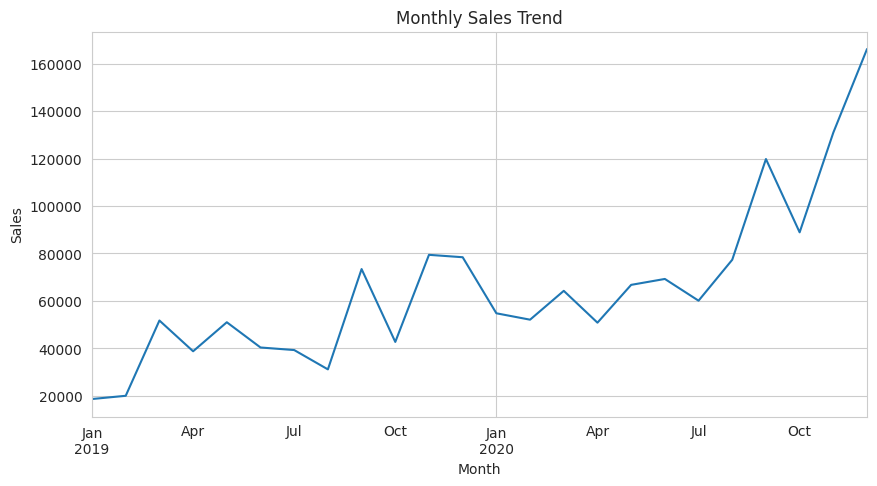

In [ ]:
#Monthly Sales Trend (Visualization 1)
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

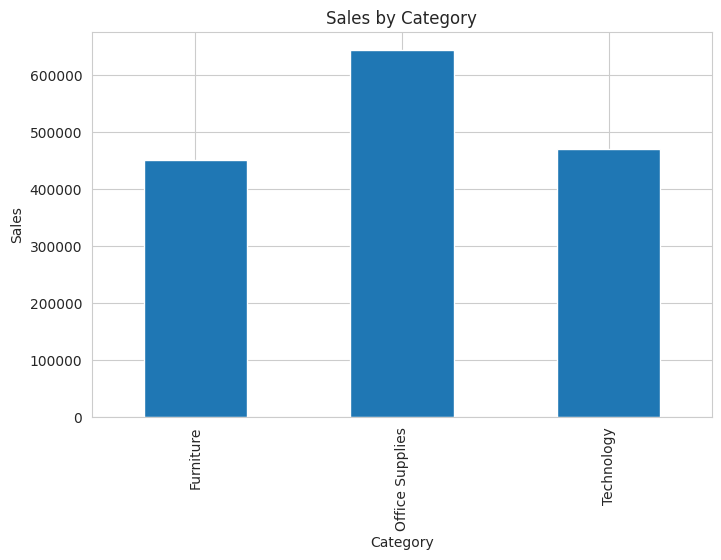

In [ ]:
#Sales by Category (Visualization 2)
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

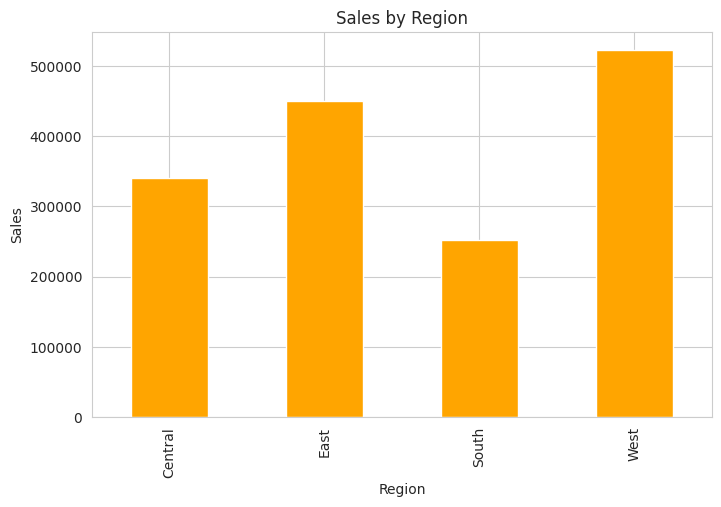

In [ ]:
#Sales by Region (Visualization 3)
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color='orange')

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

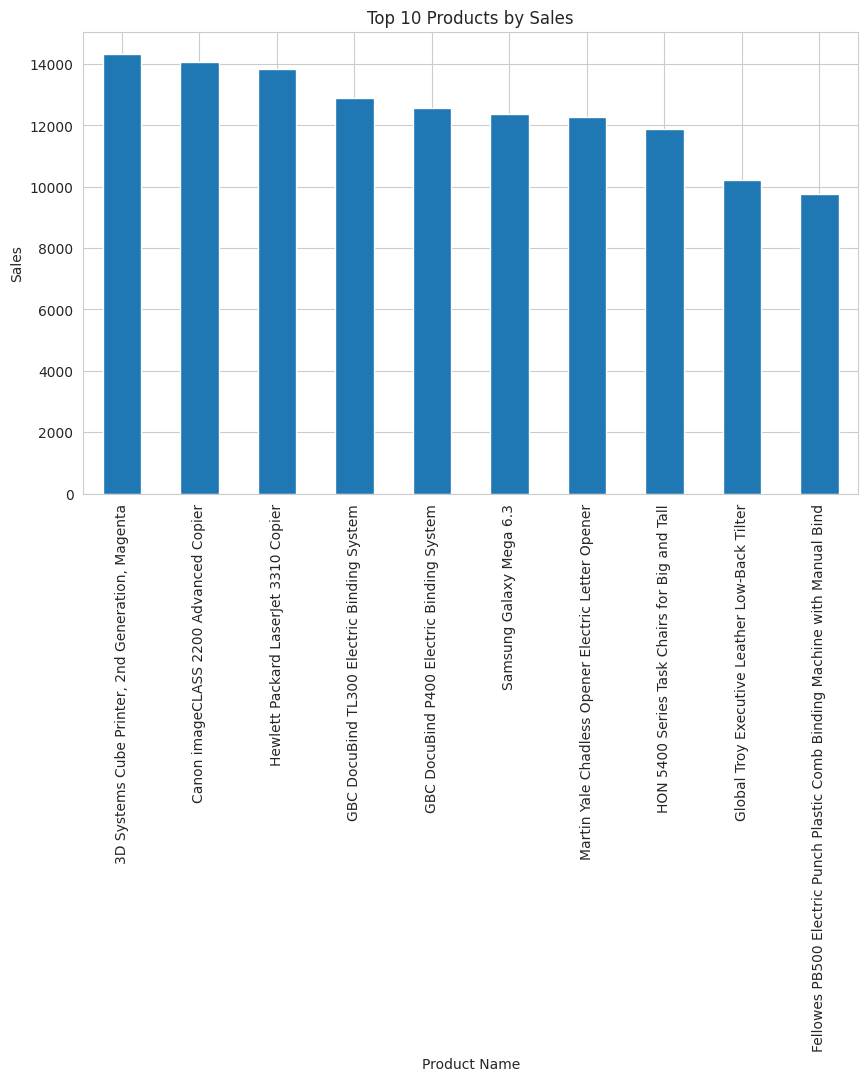

In [ ]:
#Top 10 Products (Visualization 4)
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.ylabel("Sales")

plt.show()

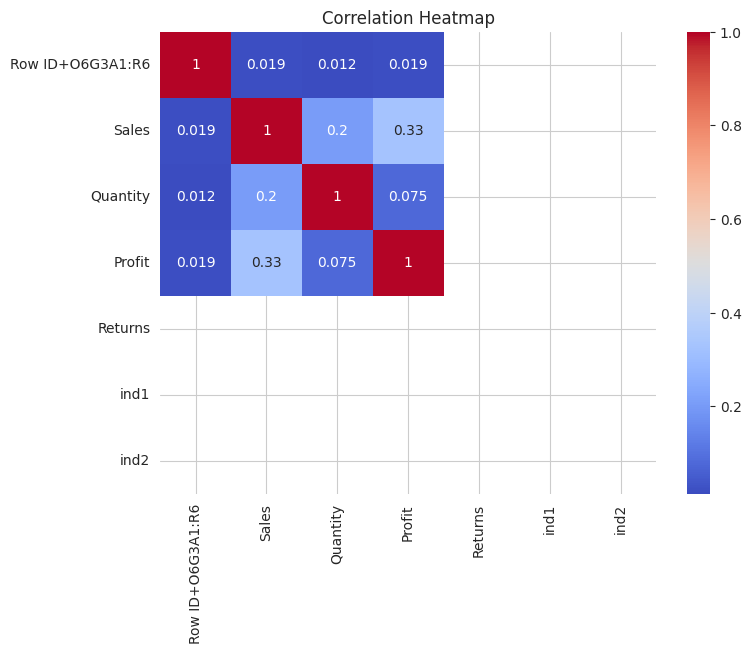

In [ ]:
#Correlation Heatmap (Visualization 5)
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

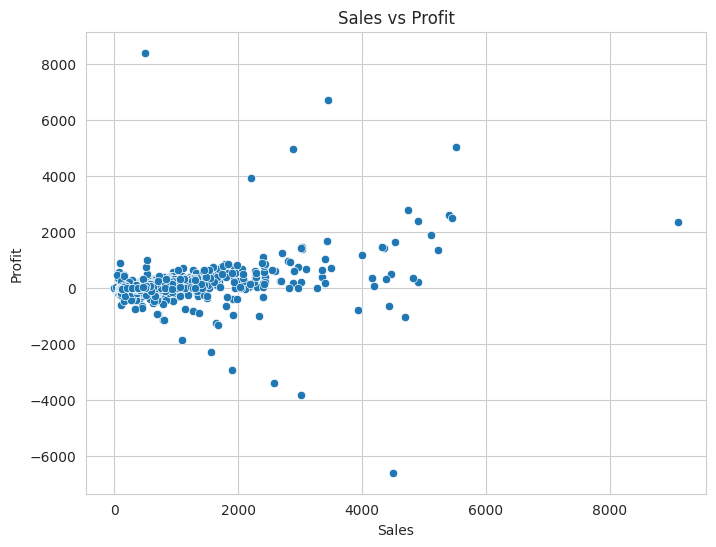

In [ ]:
#Profit vs Sales Scatter Plot (Visualization 6)
plt.figure(figsize=(8,6))

sns.scatterplot(x='Sales', y='Profit', data=df)

plt.title("Sales vs Profit")

plt.show()

In [ ]:
##Customer Segmentation (Machine Learning)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

customer_data = df.groupby('Customer ID').agg({
    'Sales':'sum',
    'Quantity':'sum'
})

scaler = StandardScaler()

scaled_data = scaler.fit_transform(customer_data)

kmeans = KMeans(n_clusters=4)

customer_data['Cluster'] = kmeans.fit_predict(scaled_data)

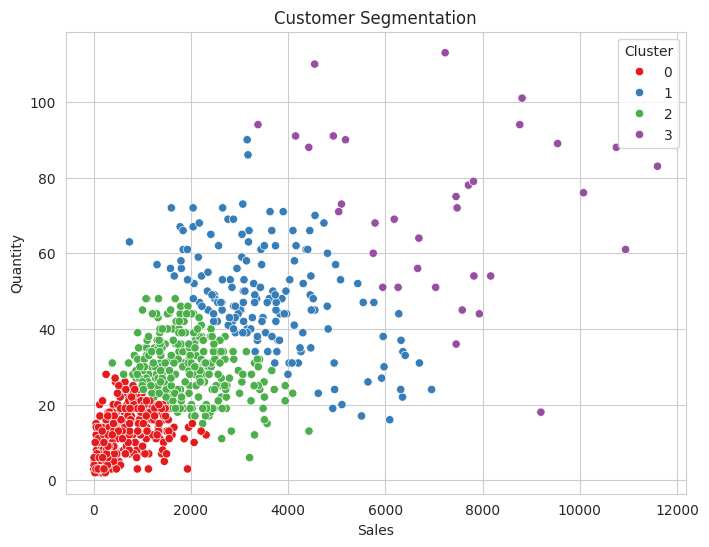

In [ ]:
#Customer Segmentation Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=customer_data['Sales'],
    y=customer_data['Quantity'],
    hue=customer_data['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")

plt.show()